<a href="https://colab.research.google.com/github/nizarASF/Filtrage-de-Spams-SMS/blob/main/notebooks/Filter_spams.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# importation des bibliothèques

import pandas as pd                                          # manipulation et analyse de donnée
import numpy as np                                           # calcul numérique et manipulation des tableaux
import matplotlib.pyplot as plt                              # visualtion graphique des données
import  seaborn as sns                                       # visualisation statistique avancée
import sklearn                                               # bibliothèque utilisée pour le Machine Learning
from sklearn.model_selection import train_test_split         # fonction permettant la division des données en ensenble d'entrainement et de test
from sklearn.feature_extraction.text import TfidfVectorizer  # transformation des données en vecteurs numériques
from sklearn.naive_bayes import MultinomialNB                # algorithme utilisé pour la classification des données
from sklearn.metrics import classification_report, accuracy_score
import nltk                                                  # utilisée pour le traitement du langage naturel
from nltk.corpus import stopwords                            # listes des stopwords qui seront supprimer lors du prétraitement
from wordcloud import WordCloud                              # génére un nuage de mots à partir des données
import string

In [7]:
df = pd.read_csv('/content/spam.csv', encoding ='latin - 1')

In [8]:
df = df[['v1', 'v2']] # séléctionner les colonnes

In [9]:
df.columns=['type','message'] #rennomer

In [10]:
print(df.head()) #visualiser les 5 premieres lignes des données

   type                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


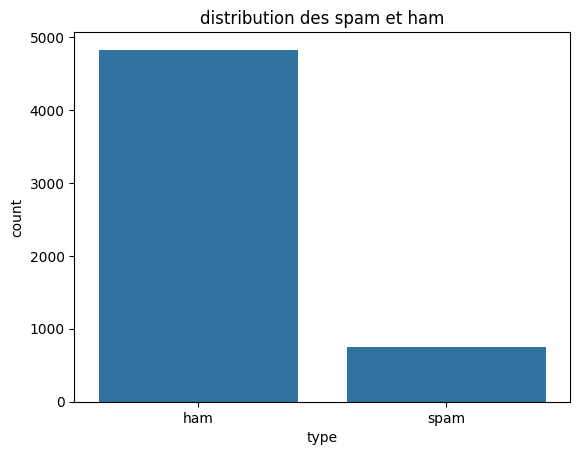

In [11]:
#distribution des classes
sns.countplot(x='type',data=df) # créer un diagramme en barre montrant le nombre d'occurence
plt.title('distribution des spam et ham')
plt.show()

In [12]:
#prétraitement des données
#télechargement stopwords
nltk.download('stopwords',quiet=True)
nltk.download('punkt_tab')
nltk.download('punkt',quiet=True) #modèle de tokenisation

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [13]:
stopW=set(stopwords.words('english')) #recupèrer la liste des mots vides en anglais et créerl'ensemble set contenant les mots vide(is,the,and...)

In [14]:
#fonction du prétraitement
def pretraitement(message):
   message=message.lower() #rendre tout les message en miniscule
   message=message.translate(str.maketrans('','',string.punctuation))#supprimer la ponctuation
   jetons=nltk.word_tokenize(message) #tokénisation
   jetons = [ mot for mot in jetons if mot not in stopW and len(mot) > 2]
   return ' '.join(jetons)

In [15]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords', quiet=True)
stopW = set(stopwords.words('english')) # Ensure stopW is defined here

df['pretraite']=df['message'].apply(pretraitement)  #appliquer la fonction de prétraitement

In [16]:
print(df.head())#visualiser à nouveau les données modifiées

   type                                            message  \
0   ham  Go until jurong point, crazy.. Available only ...   
1   ham                      Ok lar... Joking wif u oni...   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...   
3   ham  U dun say so early hor... U c already then say...   
4   ham  Nah I don't think he goes to usf, he lives aro...   

                                           pretraite  
0  jurong point crazy available bugis great world...  
1                                 lar joking wif oni  
2  free entry wkly comp win cup final tkts 21st m...  
3                      dun say early hor already say  
4        nah dont think goes usf lives around though  


In [17]:
#traitement et test
x= df['pretraite'] #variable explicative (donnée d'entrée)

In [18]:
y=df['type'].map({'ham':0,'spam':1}) #variable expliquée (étape d'encodage)

In [19]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y) # 20% test 80%train

In [20]:
from sklearn.utils import resample

# Combiner X_train et y_train dans un dataframe
train_df = pd.DataFrame({
    'message': x_train,
    'label': y_train
})

# Séparer les classes
spam = train_df[train_df.label == 1]
ham = train_df[train_df.label == 0]

# Oversampling des spam
spam_upsampled = resample(
    spam,
    replace=True,
    n_samples=len(ham),
    random_state=42
)

# Combiner
balanced_train = pd.concat([ham, spam_upsampled])

# Mélanger les données
balanced_train = balanced_train.sample(frac=1, random_state=42)

# Séparer X et y
X_train_balanced = balanced_train['message']
y_train_balanced = balanced_train['label']

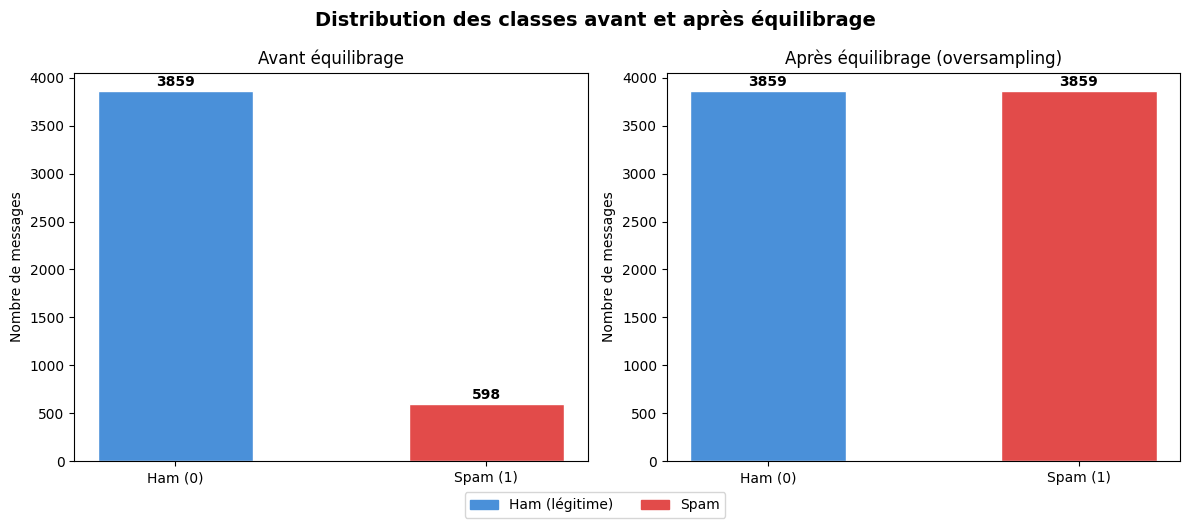

In [21]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Compter les classes avant et après équilibrage
before_counts = train_df['label'].value_counts().sort_index()
after_counts = y_train_balanced.value_counts().sort_index()

labels = ['Ham (0)', 'Spam (1)']
before_values = [before_counts.get(0, 0), before_counts.get(1, 0)]
after_values = [after_counts.get(0, 0), after_counts.get(1, 0)]

x = range(len(labels))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Distribution des classes avant et après équilibrage', fontsize=14, fontweight='bold')

# --- Avant ---
bars1 = axes[0].bar(x, before_values, width=0.5, color=['#4A90D9', '#E24B4A'], edgecolor='white')
axes[0].set_title('Avant équilibrage', fontsize=12)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylabel('Nombre de messages')
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{int(bar.get_height())}', ha='center', va='bottom', fontweight='bold')

# --- Après ---
bars2 = axes[1].bar(x, after_values, width=0.5, color=['#4A90D9', '#E24B4A'], edgecolor='white')
axes[1].set_title('Après équilibrage (oversampling)', fontsize=12)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_ylabel('Nombre de messages')
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{int(bar.get_height())}', ha='center', va='bottom', fontweight='bold')

# Légende commune
ham_patch = mpatches.Patch(color='#4A90D9', label='Ham (légitime)')
spam_patch = mpatches.Patch(color='#E24B4A', label='Spam')
fig.legend(handles=[ham_patch, spam_patch], loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.savefig('equilibrage_classes.png', bbox_inches='tight', dpi=150)
plt.show()

In [22]:
#vectorisation TF-IDF
TfIdf=TfidfVectorizer( ngram_range=(1,2),min_df=2) #création d'un objet tfIdf permettant de transformer le texte en vecteurs numériques

In [23]:
x_trainTF=TfIdf.fit_transform(x_train)#'fit':apprendre le vocabulaire d'entrainement,chaque mot est assigné à une collone du vecteur .'transform':transformer chaque texte en vecteur TF-IDF

In [24]:
x_testTF=TfIdf.transform(x_test)

In [25]:
#Naive Bayes
NaiveBayesModel=MultinomialNB() # classificateur NB adapté aux données tesxtuelles vectorisées

In [26]:
NaiveBayesModel.fit(x_trainTF,y_train) #il apprend les probabilités des mots dans chaque classe à partir de l'ensemble d'entrainement

MultinomialNB()

In [27]:
y_prediction=NaiveBayesModel.predict(x_testTF) #prédiction sur l'ensemble test

In [28]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(x_trainTF, y_train)
y_pred_lr = lr.predict(x_testTF)
print("Accuracy =", accuracy_score(y_test, y_prediction))
print(classification_report(y_test,y_prediction)) #évaluation du modèle (precision,recall,f1-score,support(nombre d'échantillons par classe))

Accuracy = 0.9641255605381166
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       966
           1       1.00      0.73      0.84       149

    accuracy                           0.96      1115
   macro avg       0.98      0.87      0.91      1115
weighted avg       0.97      0.96      0.96      1115



In [29]:
from sklearn.metrics import confusion_matrix
M=confusion_matrix(y_test, y_prediction)
print(confusion_matrix)

<function confusion_matrix at 0x7d63cc989300>


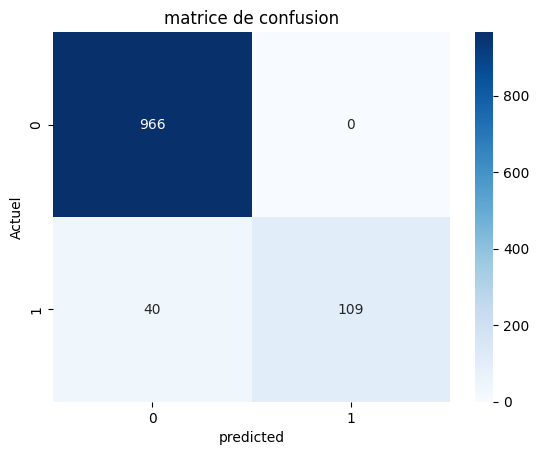

In [30]:
sns.heatmap(M, annot=True , fmt='d', cmap='Blues')
plt.title("matrice de confusion")
plt.xlabel("predicted")
plt.ylabel("Actuel")
plt.show()

In [31]:
model = LogisticRegression(max_iter=1000,C=2.0,solver='liblinear')

In [32]:
# Entraînement
model.fit(x_trainTF, y_train)

LogisticRegression(C=2.0, max_iter=1000, solver='liblinear')

In [33]:
# Prédiction
y_pred = model.predict(x_testTF)
print("Accuracy =", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy = 0.9695067264573991
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       966
           1       0.97      0.80      0.88       149

    accuracy                           0.97      1115
   macro avg       0.97      0.90      0.93      1115
weighted avg       0.97      0.97      0.97      1115



In [43]:
from sklearn.metrics import confusion_matrix
m=confusion_matrix(y_test, y_pred)
print(confusion_matrix)

<function confusion_matrix at 0x7d63cc989300>


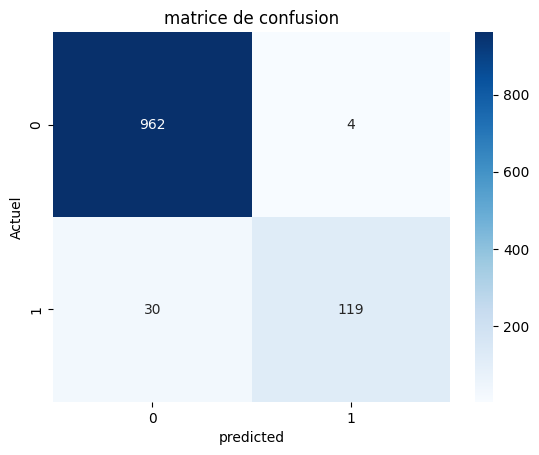

In [44]:
sns.heatmap(m, annot=True , fmt='d', cmap='Blues')
plt.title("matrice de confusion")
plt.xlabel("predicted")
plt.ylabel("Actuel")
plt.show()

In [34]:
#comparaison
print("Naive Bayes Accuracy")
print(accuracy_score(y_test, y_prediction))
print("Logistic Regression Accuracy")
print(accuracy_score(y_test,  y_pred))

Naive Bayes Accuracy
0.9641255605381166
Logistic Regression Accuracy
0.9695067264573991


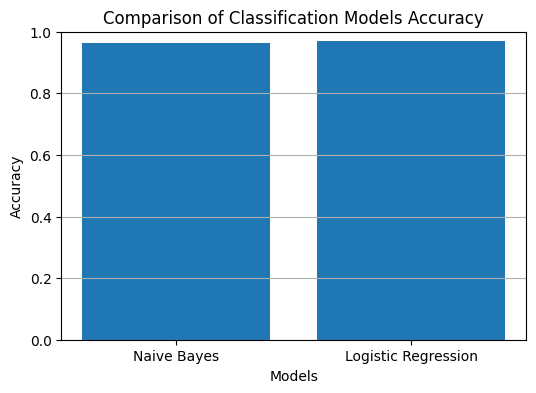

In [35]:
# Calcul des accuracies
nb_accuracy = accuracy_score(y_test, y_prediction)
lr_accuracy = accuracy_score(y_test, y_pred)
# Données du graphique
models = ["Naive Bayes", "Logistic Regression"]
values = [nb_accuracy, lr_accuracy]
# Création du plot
plt.figure(figsize=(6,4))
plt.bar(models, values)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Comparison of Classification Models Accuracy")
plt.ylim(0,1)
plt.grid(axis='y')
plt.show()

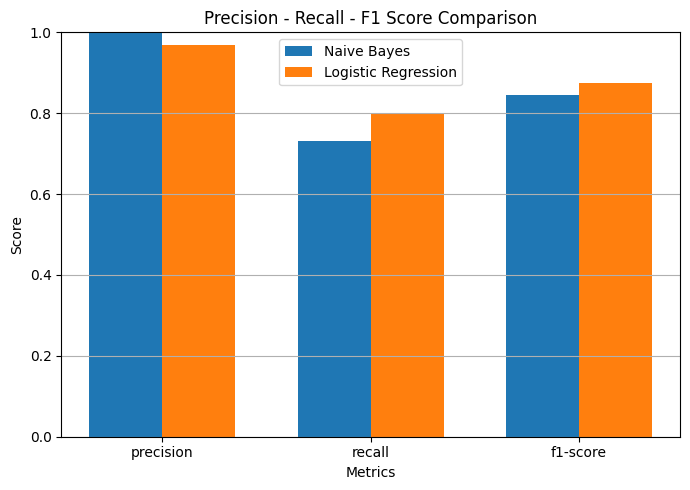

In [36]:
# Calcul du rapport de classification pour le modèle Naive Bayes
# output_dict=True permet d'obtenir les résultats sous forme de dictionnaire Python
nb_report = classification_report(y_test, y_prediction, output_dict=True)
# Calcul du rapport de classification pour le modèle Logistic Regression
lr_report = classification_report(y_test, y_pred, output_dict=True)
# Liste des métriques utilisées pour la comparaison des modèles
# Precision = exactitude des prédictions positives
# Recall = capacité du modèle à détecter les vrais positifs
# F1-score = moyenne harmonique entre precision et recall
metrics = ["precision", "recall", "f1-score"]
# Extraction des valeurs des métriques pour la classe spam (classe 1)
# nb_report["1"] signifie les performances pour la classe spam
nb_values = [nb_report["1"][m] for m in metrics]
# Extraction des valeurs des métriques pour Logistic Regression
lr_values = [lr_report["1"][m] for m in metrics]
# Création d'un tableau de positions pour les barres du graphique
x = np.arange(len(metrics))
# Largeur des barres du graphique
width = 0.35
# Création de la figure graphique avec taille définie
plt.figure(figsize=(7,5))
# Tracer les barres du modèle Naive Bayes
plt.bar(x - width/2, nb_values, width, label="Naive Bayes")
# Tracer les barres du modèle Logistic Regression
plt.bar(x + width/2, lr_values, width, label="Logistic Regression")
# Nom de l’axe des abscisses (axe horizontal)
plt.xlabel("Metrics")
# Nom de l’axe des ordonnées (axe vertical)
plt.ylabel("Score")
# Titre du graphique
plt.title("Precision - Recall - F1 Score Comparison")
# Définir les noms des colonnes sur l’axe X
plt.xticks(x, metrics)
# Limiter l’axe Y entre 0 et 1 car les scores sont des probabilités
plt.ylim(0,1)
# Afficher la légende pour différencier les modèles
plt.legend()
# Ajouter une grille pour faciliter la lecture du graphique
plt.grid(axis='y')
# Ajuster automatiquement la mise en page
plt.tight_layout()
# Afficher le graphique final
plt.show()


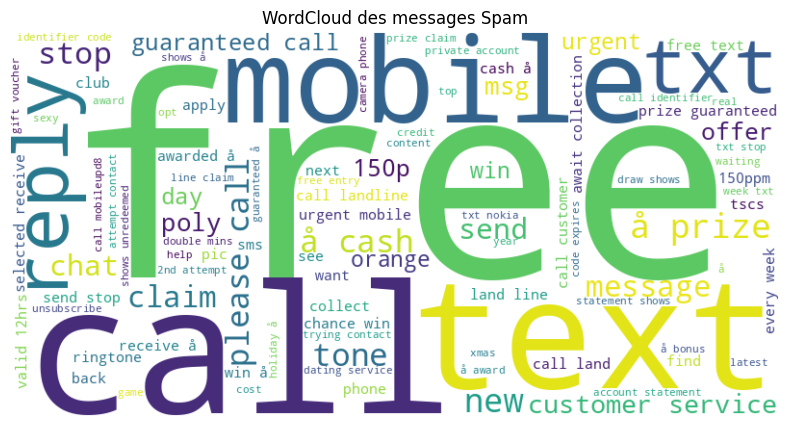

In [37]:
# Sélectionner seulement les messages spam
spam_text = " ".join(df[df['type']=="spam"]['pretraite'])  # concaténer tous les messages spam prétraités
# Générer le WordCloud
wordcloud = WordCloud(  # créer un objet WordCloud
    width=800,  # largeur de l'image du nuage de mots
    height=400,  # hauteur de l'image
    max_words=100,  # nombre maximum de mots affichés
    background_color='white'  # couleur du fond
).generate(spam_text)  # générer le nuage de mots à partir du texte spam
# Afficher le graphique
plt.figure(figsize=(10,5))  # créer une figure avec une taille spécifique
plt.imshow(wordcloud, interpolation='bilinear')  # afficher l'image du wordcloud
plt.axis("off")  # supprimer les axes
plt.title("WordCloud des messages Spam")  # ajouter un titre
plt.show()  # afficher le graphique

In [38]:
def tester_message(message):
    # Prétraitement du message
    message_clean = pretraitement(message)
    # Vectorisation TF-IDF
    message_vector = TfIdf.transform([message_clean])
    # Prédiction Naive Bayes
    nb_result = NaiveBayesModel.predict(message_vector)[0]
    # Prédiction Logistic Regression
    lr_result = lr.predict(message_vector)[0]
    print("\nMessage :", message)
    print("Prediction Naive Bayes :", "Spam" if nb_result==1 else "Ham")
    print("Prediction Logistic Regression :", "Spam" if lr_result==1 else "Ham")

In [39]:
 tester_message("Congratulations you won 1000 dollars")


Message : Congratulations you won 1000 dollars
Prediction Naive Bayes : Ham
Prediction Logistic Regression : Ham


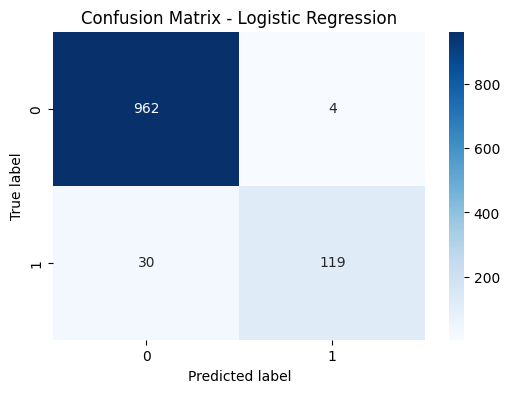

In [40]:
cm = confusion_matrix(y_test, y_pred)  # calculer la matrice de confusion entre les vraies valeurs et les prédictions

plt.figure(figsize=(6,4))  # définir la taille de la figure

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')  # afficher la matrice sous forme de heatmap (table colorée)

plt.xlabel("Predicted label")  # nom de l'axe des prédictions du modèle
plt.ylabel("True label")  # nom de l'axe des vraies valeurs
plt.title("Confusion Matrix - Logistic Regression")  # titre du graphique

plt.show()  # afficher le graphique

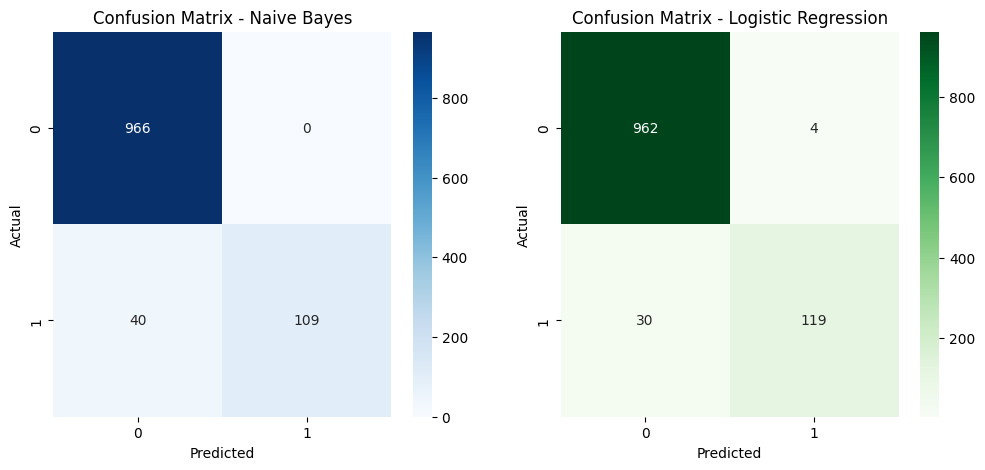

In [41]:
# matrice de confusion Naive Bayes
cm_nb = confusion_matrix(y_test, y_prediction)  # calcul matrice NB
# matrice de confusion Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred)  # calcul matrice LR
# créer une figure avec deux graphiques
plt.figure(figsize=(12,5))
# Matrice Naive Bayes
plt.subplot(1,2,1)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues')  # afficher matrice
plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
# Matrice Logistic Regression
plt.subplot(1,2,2)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens')  # afficher matrice
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()